In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

## Basic Data Exploration (EDA)

In [2]:
df = pd.read_csv('customer_churn_dataset.csv')

print(df.shape)
print(df.columns)
df.head()

(10000, 21)
Index(['CustomerID', 'Gender', 'Age', 'SubscriptionType', 'MonthlySpend',
       'TotalWatchTime', 'ComplaintCount', 'DaysSinceLastLogin', 'Churn',
       'AvgSessionDuration', 'NumDevicesUsed', 'ContentPreferenceScore',
       'ActiveDaysLastMonth', 'BingeWatchRatio', 'SkippedContentCount',
       'DiscountReceived', 'LoyaltyScore', 'PlatformType',
       'AdInteractionCount', 'ReferredFriendsCount', 'SocialMediaMentions'],
      dtype='object')


,CustomerID,Gender,Age,SubscriptionType,MonthlySpend,TotalWatchTime,ComplaintCount,DaysSinceLastLogin,Churn,AvgSessionDuration,...,ContentPreferenceScore,ActiveDaysLastMonth,BingeWatchRatio,SkippedContentCount,DiscountReceived,LoyaltyScore,PlatformType,AdInteractionCount,ReferredFriendsCount,SocialMediaMentions
0,1,Male,68,Basic,11.35,27,2,57,0,208.32,...,33.0,5,5.40,3,3.16,9.850000,Mobile,18.0,2,9
1,2,Female,57,Standard,30.87,15,0,48,1,289.54,...,62.0,26,0.58,9,5.73,8.290000,TV,5.0,0,18
2,3,Male,24,Basic,32.16,0,1,34,1,194.16,...,NaN,9,0.00,2,18.09,-1.772388,Mobile,33.0,1,16
3,4,Male,49,Standard,35.91,21,0,35,0,245.60,...,90.0,2,10.50,4,19.78,2.380000,Mobile,10.0,8,16
4,5,Male,65,Standard,22.71,0,2,4,0,271.02,...,42.0,15,NaN,12,15.41,4.370000,Mobile,2.0,4,8


## Dataset Overview

We are analyzing a customer dataset to predict churn behavior.

- Total Customers: 10,000
- Features: 21
- Objective: Predict whether a customer will churn

## Check Data Types & Missing Values

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              10000 non-null  int64  
 1   Gender                  10000 non-null  object 
 2   Age                     10000 non-null  int64  
 3   SubscriptionType        10000 non-null  object 
 4   MonthlySpend            10000 non-null  float64
 5   TotalWatchTime          10000 non-null  int64  
 6   ComplaintCount          10000 non-null  int64  
 7   DaysSinceLastLogin      10000 non-null  int64  
 8   Churn                   10000 non-null  int64  
 9   AvgSessionDuration      10000 non-null  float64
 10  NumDevicesUsed          10000 non-null  int64  
 11  ContentPreferenceScore  9000 non-null   float64
 12  ActiveDaysLastMonth     10000 non-null  int64  
 13  BingeWatchRatio         9000 non-null   float64
 14  SkippedContentCount     10000 non-null 

,CustomerID,Age,MonthlySpend,TotalWatchTime,ComplaintCount,DaysSinceLastLogin,Churn,AvgSessionDuration,NumDevicesUsed,ContentPreferenceScore,ActiveDaysLastMonth,BingeWatchRatio,SkippedContentCount,DiscountReceived,LoyaltyScore,AdInteractionCount,ReferredFriendsCount,SocialMediaMentions
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,9000.000000,10000.000000,9000.000000,10000.000000,10000.000000,10000.000000,9000.000000,10000.000000,10000.000000
mean,5000.50000,43.316500,28.578830,24.501400,1.000300,29.457000,0.197200,153.449057,2.510900,50.146835,15.003500,3.965676,9.636500,10.008391,4.965827,24.631111,4.450700,9.492000
std,2886.89568,14.942043,18.032781,14.427551,1.001299,17.238488,0.397905,84.909956,1.123747,29.144203,8.933838,7.355427,5.960866,5.773516,2.939968,14.397047,2.889361,5.707608
min,1.00000,18.000000,5.000000,0.000000,0.000000,0.000000,0.000000,5.040000,1.000000,-18.674969,0.000000,0.000000,0.000000,0.010000,-5.379779,0.000000,0.000000,0.000000
25%,2500.75000,30.000000,16.487500,12.000000,0.000000,14.000000,0.000000,79.205000,1.000000,25.000000,7.000000,0.800000,5.000000,4.990000,2.430000,12.000000,2.000000,5.000000
50%,5000.50000,43.000000,27.845000,25.000000,1.000000,30.000000,0.000000,154.925000,3.000000,50.000000,15.000000,1.610000,10.000000,10.000000,4.951940,25.000000,4.000000,9.000000
75%,7500.25000,56.000000,38.890000,37.000000,2.000000,44.000000,0.000000,227.545000,4.000000,76.000000,23.000000,3.330000,15.000000,14.962500,7.501691,37.000000,7.000000,14.000000
max,10000.00000,69.000000,247.300000,49.000000,8.000000,59.000000,1.000000,299.960000,4.000000,113.442819,30.000000,49.000000,38.000000,20.000000,13.495991,49.000000,9.000000,19.000000


## Data Understanding

The dataset consists of:
- Numerical features: Spend, engagement, activity metrics
- Categorical features: Gender, SubscriptionType, PlatformType
- Target variable: Churn (0 = Retained, 1 = Churned)

## Check Target Distribution

Churn
0    80.28
1    19.72
Name: proportion, dtype: float64


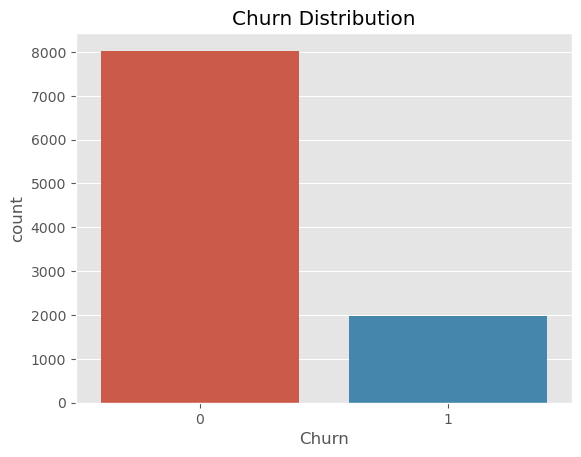

In [4]:
churn_dist = df['Churn'].value_counts(normalize=True) * 100
print(churn_dist)

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

## Churn Rate Analysis

- ~20% of customers are churning
- ~80% are retained

### Insight
This indicates a moderate churn problem and highlights an opportunity for targeted retention strategies.

### Important Note
The dataset is imbalanced, which means special handling (like SMOTE) is required during modeling.

# Visual Analysis

## Days Since Last Login

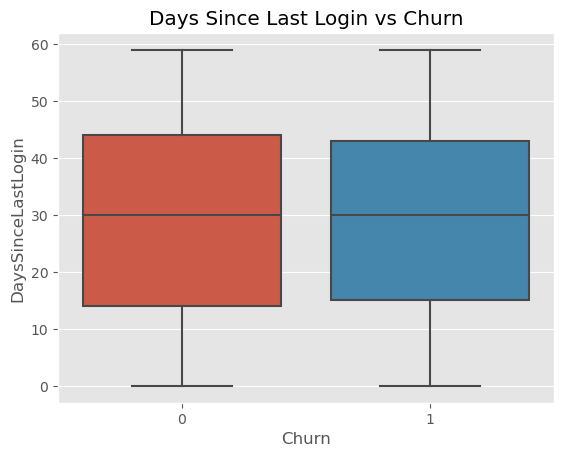

In [5]:
sns.boxplot(x='Churn', y='DaysSinceLastLogin', data=df)
plt.title("Days Since Last Login vs Churn")
plt.show()

## Inactivity vs Churn

### Observation
The distribution of "Days Since Last Login" is highly overlapping between churned and retained customers.

### Stakeholder Insight
Inactivity does not strongly differentiate churned customers in this dataset.

### Conclusion
Inactivity alone is not a reliable predictor of churn.

# ActiveDaysLastMonth

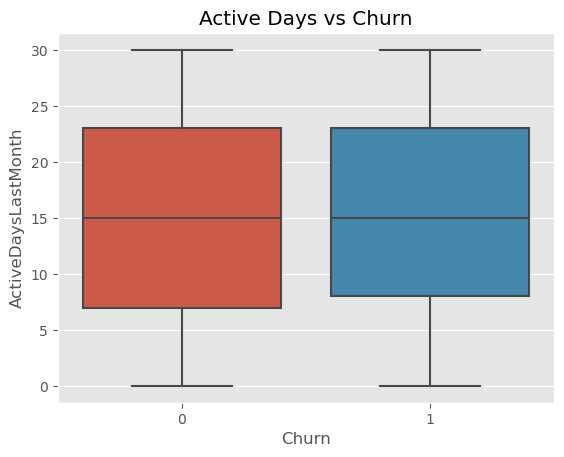

In [6]:
sns.boxplot(x='Churn', y='ActiveDaysLastMonth', data=df)
plt.title("Active Days vs Churn")
plt.show()

## Engagement vs Churn

Observation:
High overlap between churned and retained users.

Insight:
Engagement alone is not sufficient to explain churn.

## Loyalty vs Churn

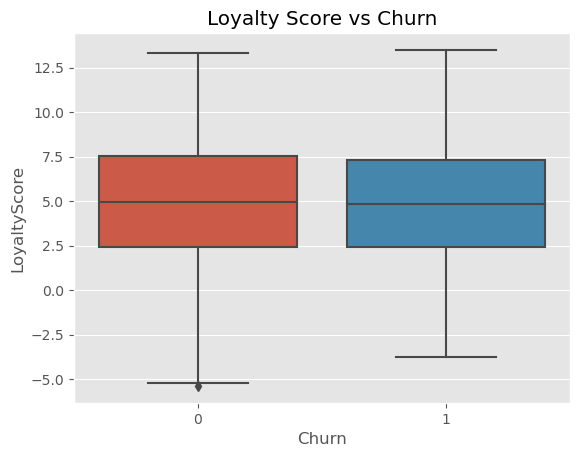

In [7]:
sns.boxplot(x='Churn', y='LoyaltyScore', data=df)
plt.title("Loyalty Score vs Churn")
plt.show()

## Loyalty vs Churn

### Observation
Churned customers show slightly lower loyalty scores compared to retained customers.

### Stakeholder Insight
Lower loyalty contributes to churn risk, but the difference is not strong enough to act as a standalone predictor.

### Conclusion
Loyalty is a contributing factor, but not a dominant one.

## Key Insight from EDA

No single feature strongly explains churn.

- High overlap across variables
- Weak individual signals

Conclusion:
Churn is a multi-dimensional problem requiring machine learning.

## Data Cleaning

In [8]:
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

## Data Cleaning

- Missing numerical values → filled using median
- Missing categorical values → filled using mode

### Stakeholder Insight
This ensures data consistency without introducing bias from extreme values.

## Outlier Handling

In [9]:
for col in numeric_cols:
    upper = df[col].quantile(0.99)
    df[col] = np.where(df[col] > upper, upper, df[col])

## Feature Engineering

In [10]:
df['EngagementScore'] = (
    df['ActiveDaysLastMonth']/30 +
    df['AvgSessionDuration']/df['AvgSessionDuration'].max() +
    df['TotalWatchTime']/df['TotalWatchTime'].max()
)

df['InactivityScore'] = df['DaysSinceLastLogin'] + df['SkippedContentCount']

df['ValueScore'] = df['MonthlySpend'] / (df['TotalWatchTime'] + 1)

# --- RFM (keep)
df['Recency'] = df['DaysSinceLastLogin']
df['Frequency'] = df['ActiveDaysLastMonth']
df['Monetary'] = df['MonthlySpend']

# --- Strong interaction features
df['Watch_per_ActiveDay'] = df['TotalWatchTime'] / (df['ActiveDaysLastMonth'] + 1)

df['Session_per_Day'] = df['AvgSessionDuration'] / (df['ActiveDaysLastMonth'] + 1)

df['Skip_Ratio'] = df['SkippedContentCount'] / (df['TotalWatchTime'] + 1)

df['Engagement_vs_Inactivity'] = df['ActiveDaysLastMonth'] / (df['DaysSinceLastLogin'] + 1)

## Feature Engineering

We created composite features to better capture customer behavior:

- EngagementScore → overall activity level
- InactivityScore → disengagement signal
- ValueScore → perceived value of service

### Stakeholder Insight
Since individual features were weak predictors, combining them helps uncover stronger behavioral patterns.

## Encoding

In [11]:
df = pd.get_dummies(df, columns=['Gender', 'SubscriptionType', 'PlatformType'], drop_first=True)

## Encoding

Categorical variables were converted into numerical format for machine learning compatibility.

## Model Preparation

In [12]:
from sklearn.model_selection import train_test_split

df = df.drop('CustomerID', axis=1)

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Data Splitting

- 80% training data
- 20% testing data
- Stratified split to maintain churn distribution

### Stakeholder Insight
Ensures reliable and unbiased model evaluation.

## Scaling + SMOTE

In [13]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

## Handling Imbalance

Used SMOTE to balance churn vs non-churn customers.

### Stakeholder Insight
This improves the model’s ability to learn churn behavior and reduces bias toward retained customers.

## Model Training

In [14]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.85,
    colsample_bytree=0.8,
    gamma=1,
    reg_lambda=2,
    reg_alpha=1,
    eval_metric='auc',
    random_state=42
)

model.fit(X_res, y_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=1, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=500, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=42, ...)

## Model Selection

We use XGBoost to capture complex relationships between features.

### Stakeholder Insight
Model identifies patterns not visible in individual variables.

## Evaluation

In [18]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]

print("\n--- Model Performance Metrics ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_probs):.4f}")


--- Model Performance Metrics ---
              precision    recall  f1-score   support

         0.0       0.80      1.00      0.89      1606
         1.0       0.00      0.00      0.00       394

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.45      2000
weighted avg       0.64      0.80      0.72      2000

ROC-AUC Score: 0.5180


## Model Performance

ROC-AUC measures how well the model separates churn vs non-churn.

Insight:
The current model shows limited predictive performance (ROC-AUC ~0.52), indicating that the available features do not strongly differentiate churn behavior. This suggests that churn is influenced by factors not captured in the dataset or requires richer feature engineering.

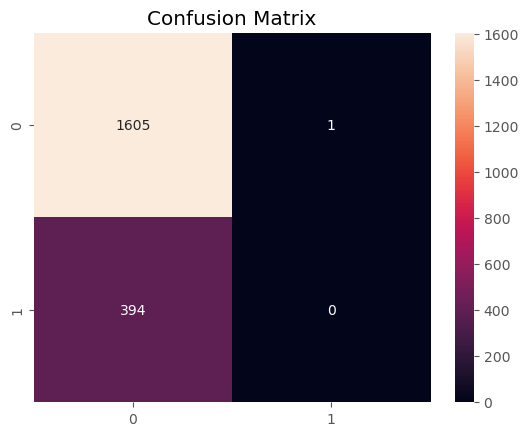

In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

## Feature Importance

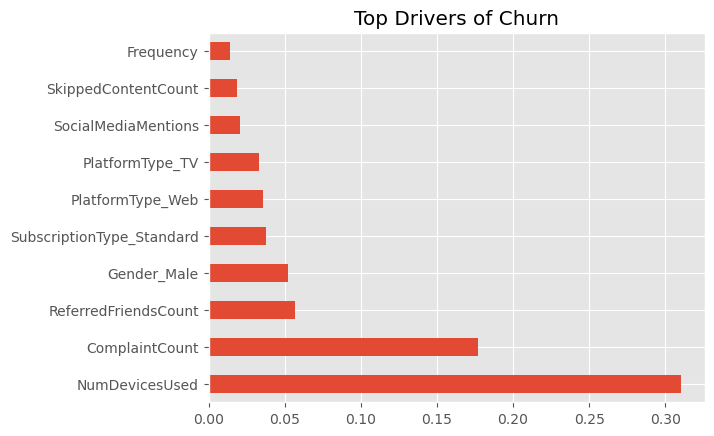

In [20]:
feat_importance = pd.Series(model.feature_importances_, index=X.columns)
feat_importance.nlargest(10).plot(kind='barh')
plt.title("Top Drivers of Churn")
plt.show()

# Key Drivers of churn

Top features influencing churn provide actionable insights for business decisions.

# Final  Output

In [21]:
results = pd.DataFrame(X_test, columns=X.columns)
results['Actual_Churn'] = y_test.values
results['Churn_Probability'] = y_probs

results.sort_values(by='Churn_Probability', ascending=False).head(10)

,Age,MonthlySpend,TotalWatchTime,ComplaintCount,DaysSinceLastLogin,AvgSessionDuration,NumDevicesUsed,ContentPreferenceScore,ActiveDaysLastMonth,BingeWatchRatio,...,Session_per_Day,Skip_Ratio,Engagement_vs_Inactivity,Gender_Male,SubscriptionType_Premium,SubscriptionType_Standard,PlatformType_TV,PlatformType_Web,Actual_Churn,Churn_Probability
1147,-0.152257,-1.315689,-1.281385,-1.008801,1.258456,-0.558601,-1.339811,-1.083732,-0.218097,-0.307343,...,-0.355704,0.325151,-0.343869,-0.9995,-0.504683,-0.824815,-0.503708,-0.647841,0.0,0.504444
900,0.450477,0.683157,-0.242010,-1.008801,-1.072220,1.526750,-1.339811,0.765013,0.900921,-0.410161,...,-0.233936,-0.354579,0.264554,-0.9995,-0.504683,1.212394,-0.503708,1.543588,0.0,0.499647
1674,-1.223784,-0.393616,-1.350677,-1.008801,0.267918,-1.204917,-1.339811,-0.684983,-1.001409,-0.421911,...,-0.363735,0.742787,-0.372552,-0.9995,-0.504683,-0.824815,-0.503708,-0.647841,0.0,0.497710
493,0.182595,0.565984,-0.242010,0.003036,-0.839153,-0.300451,-1.339811,0.946262,1.348528,-0.429255,...,-0.442050,-0.174543,0.180896,-0.9995,-0.504683,-0.824815,-0.503708,-0.647841,0.0,0.492436
1269,0.651388,-0.579715,0.312324,-1.008801,-0.489551,1.245615,-1.339811,0.728763,-0.106195,-0.239777,...,-0.076042,-0.464316,-0.202825,1.0005,-0.504683,1.212394,-0.503708,-0.647841,0.0,0.485495
1033,1.655945,0.594320,-0.727052,1.014872,-1.013953,0.913675,-1.339811,0.221264,-0.218097,-0.307343,...,-0.098499,0.007209,-0.070078,-0.9995,1.981441,-0.824815,-0.503708,1.543588,0.0,0.471188
650,-0.286198,-0.487814,-0.796344,0.003036,0.209652,-0.597028,-1.339811,0.003765,1.012823,-0.464507,...,-0.455291,-0.038597,-0.177447,1.0005,-0.504683,-0.824815,-0.503708,-0.647841,0.0,0.468749
344,0.517447,-0.838570,-1.697136,-1.008801,-0.722619,-1.484402,-0.451121,1.018762,0.453314,-0.543823,...,-0.534256,0.082652,-0.049798,-0.9995,-0.504683,1.212394,-0.503708,-0.647841,0.0,0.468564
1966,0.182595,-0.804873,0.035157,0.003036,0.734054,-0.965981,-1.339811,-1.047482,0.565216,-0.360221,...,-0.475747,-0.265550,-0.265340,-0.9995,1.981441,-0.824815,-0.503708,-0.647841,1.0,0.466535
407,-0.085287,1.223842,-1.142802,0.003036,-0.023416,-1.490295,-0.451121,-1.228732,-0.329998,-0.445412,...,-0.514237,-0.294567,-0.289111,-0.9995,-0.504683,-0.824815,-0.503708,1.543588,0.0,0.463757


## Final Output: Customer Risk Scoring

generated a ranked list of customers based on churn probability.

### Business Value
- High-risk customers → Immediate retention action
- Medium-risk → Engagement campaigns
- Low-risk → Maintain experience

### Conclusion
Churn is driven by a combination of behavioral factors rather than a single variable.  
Machine learning enables us to identify high-risk customers and take proactive retention actions.

In [22]:
import shap

In [23]:
X_train_original = X_train.copy()
X_test_original = X_test.copy()

In [24]:
explainer = shap.Explainer(model, X_train_original)
shap_values = explainer(X_test_original)

 98%|===================| 1953/2000 [00:30<00:00]        

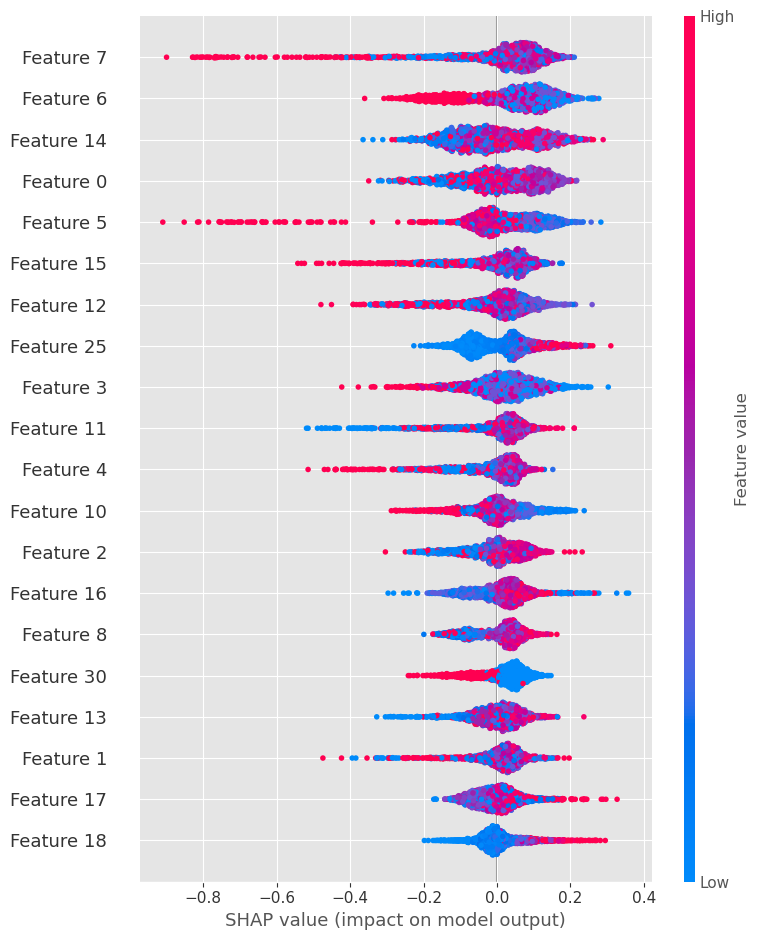

In [25]:
shap.summary_plot(shap_values, X_test_original)

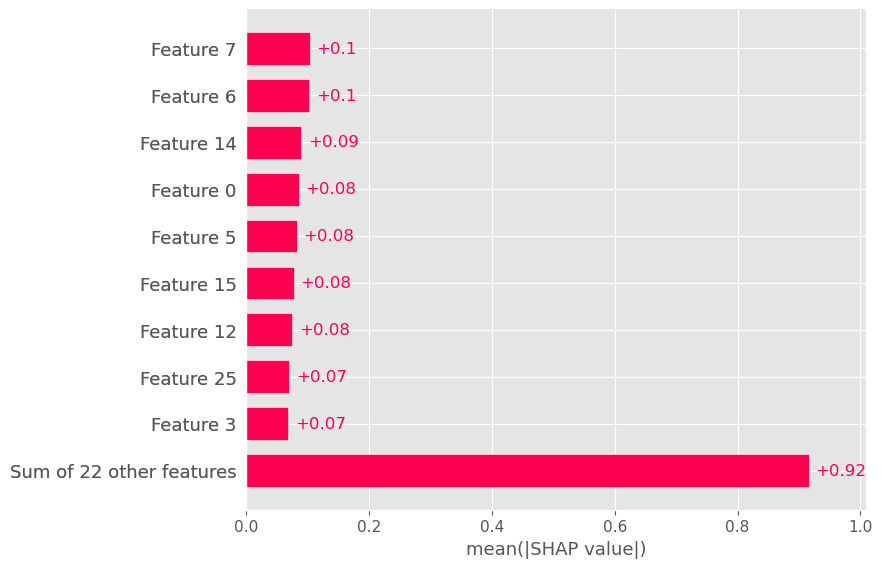

In [26]:
shap.plots.bar(shap_values)

## SHAP Feature Importance 

This plot shows the impact of each feature on churn prediction.

- Features at the top → most important
- Red → higher feature values
- Blue → lower feature values

### Stakeholder Insight
SHAP provides a transparent view of how each feature influences churn predictions across all customers.

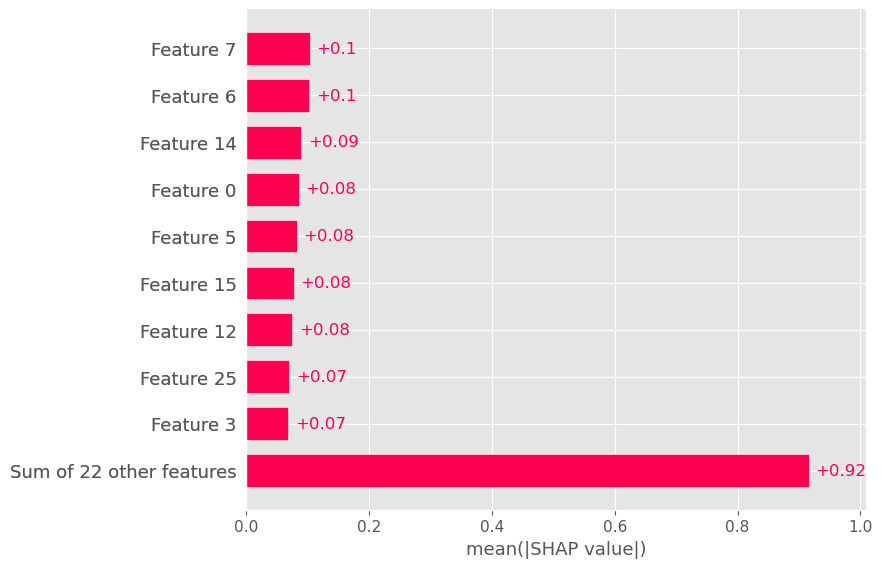

In [27]:
shap.plots.bar(shap_values)

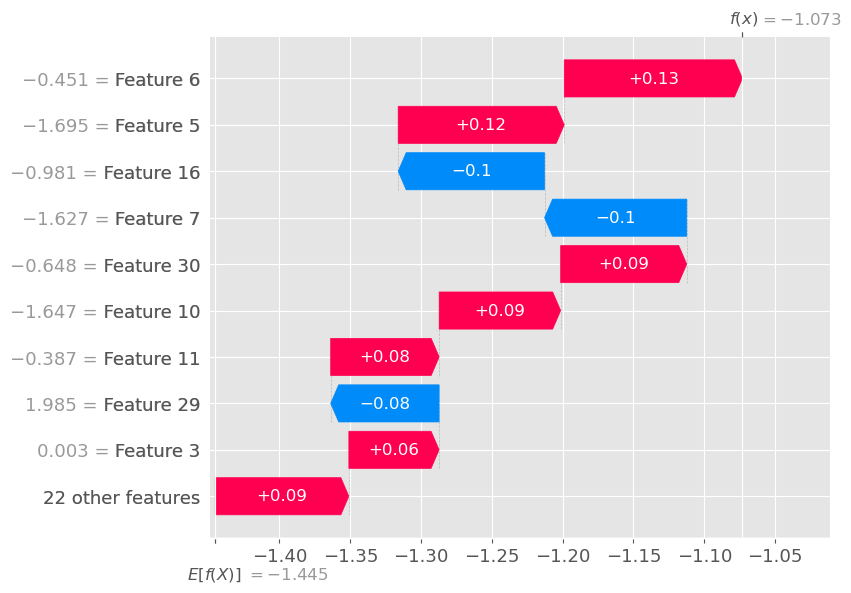

In [28]:
shap.plots.waterfall(shap_values[0])

## Individual Customer Explanation

This visualization explains why a specific customer is predicted to churn.

### How to Read:
- Red → increases churn probability
- Blue → decreases churn probability

###  Insight
This enables personalized decision-making for retention strategies.

In [29]:
import pandas as pd

shap_df = pd.DataFrame(shap_values.values, columns=X.columns)
shap_df['Churn_Probability'] = y_probs
shap_df['Actual_Churn'] = y_test.values

In [30]:
def segment_customer(prob):
    if prob >= 0.7:
        return "High Risk"
    elif prob >= 0.4:
        return "Medium Risk"
    else:
        return "Low Risk"

shap_df['Risk_Segment'] = shap_df['Churn_Probability'].apply(segment_customer)

shap_df['Risk_Segment'].value_counts()

Risk_Segment
Low Risk       1945
Medium Risk      55
Name: count, dtype: int64

## Customer Segmentation

Customers are grouped based on churn probability:

- High Risk (≥ 70%)
- Medium Risk (40%–70%)
- Low Risk (< 40%)

###  Insight
This segmentation enables targeted retention strategies instead of one-size-fits-all approaches.

# High-Risk Customers

In [31]:
high_risk = shap_df[shap_df['Risk_Segment'] == 'High Risk']

high_risk

,Age,MonthlySpend,TotalWatchTime,ComplaintCount,DaysSinceLastLogin,AvgSessionDuration,NumDevicesUsed,ContentPreferenceScore,ActiveDaysLastMonth,BingeWatchRatio,...,Skip_Ratio,Engagement_vs_Inactivity,Gender_Male,SubscriptionType_Premium,SubscriptionType_Standard,PlatformType_TV,PlatformType_Web,Churn_Probability,Actual_Churn,Risk_Segment


In [32]:
medium_risk = shap_df[shap_df['Risk_Segment'] == 'Medium Risk']

medium_risk

,Age,MonthlySpend,TotalWatchTime,ComplaintCount,DaysSinceLastLogin,AvgSessionDuration,NumDevicesUsed,ContentPreferenceScore,ActiveDaysLastMonth,BingeWatchRatio,...,Skip_Ratio,Engagement_vs_Inactivity,Gender_Male,SubscriptionType_Premium,SubscriptionType_Standard,PlatformType_TV,PlatformType_Web,Churn_Probability,Actual_Churn,Risk_Segment
97,0.189903,0.137862,-0.052918,0.255405,0.035373,0.109153,0.164733,0.136649,0.042889,-0.038926,...,-0.009993,-0.030300,0.023573,-0.010059,-0.022480,0.024687,0.071848,0.423876,0.0,Medium Risk
221,0.100431,-0.012616,0.034057,0.073379,0.039885,0.099889,-0.060919,0.096379,0.050610,0.059784,...,0.044484,0.010041,0.033065,0.073249,0.019326,0.046608,-0.006906,0.416637,0.0,Medium Risk
297,-0.044087,0.063988,0.078869,-0.005158,0.037663,0.064877,0.077507,0.099184,0.079019,-0.011104,...,0.025583,0.039399,0.040738,-0.022747,-0.032043,0.025456,0.017368,0.406729,0.0,Medium Risk
298,0.041847,0.033121,0.058984,-0.033724,0.060146,0.098896,0.147922,0.026236,0.030986,0.059966,...,0.003879,0.055508,0.058115,-0.020676,0.023788,-0.019756,0.039257,0.453582,1.0,Medium Risk
344,0.024879,0.035222,-0.046060,0.179643,0.013469,0.084374,0.111084,0.065460,0.039691,-0.077508,...,0.007095,0.039412,0.034324,-0.007346,-0.000796,0.023254,0.065868,0.468564,0.0,Medium Risk
362,0.118059,0.104264,0.016328,-0.047857,0.039773,-0.043634,0.151701,0.073168,-0.004105,0.002364,...,0.038237,0.087859,0.039008,-0.004045,0.013791,0.051863,-0.008608,0.415825,0.0,Medium Risk
388,0.169680,0.046855,0.026365,0.182631,0.024380,0.106111,0.104605,0.130387,0.028369,0.003424,...,-0.005075,0.036435,-0.006031,-0.012433,0.003496,0.018353,-0.082250,0.406415,0.0,Medium Risk
398,-0.169202,-0.060317,-0.062315,0.118826,-0.014659,0.195449,-0.029558,0.056871,0.038539,0.014355,...,0.153524,0.086530,0.066498,-0.002176,-0.007060,0.039039,0.033478,0.429935,0.0,Medium Risk
407,0.141295,0.077362,-0.016476,0.006100,0.083251,0.157154,0.096464,0.024528,0.034489,0.029519,...,0.003887,-0.050720,-0.033933,-0.008126,-0.006448,0.010455,-0.158381,0.463757,0.0,Medium Risk
461,-0.000337,0.057111,0.043792,0.142399,0.014172,0.036887,0.158601,0.133438,0.010867,0.000649,...,0.094704,-0.008794,-0.002973,-0.013051,0.012288,0.043521,0.001952,0.425842,1.0,Medium Risk


## Medium-Risk Customers – SHAP Insights

### Observation
Customers show moderate signals across engagement and loyalty.

### Stakeholder Insight
These customers are at a tipping point and can be retained with timely intervention.

### Business Action
- Engagement campaigns
- Content recommendations
- Incentives to increase activity

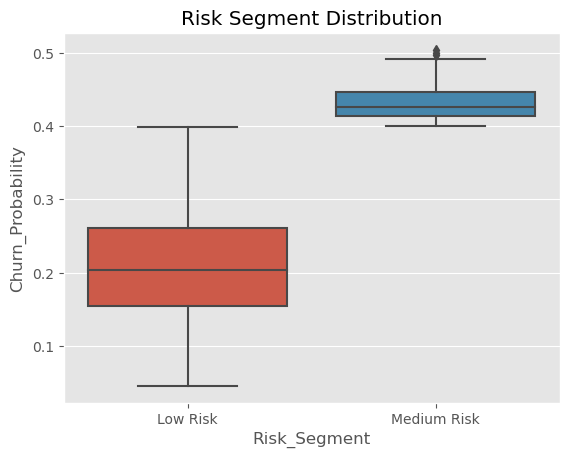

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Risk_Segment', y='Churn_Probability', data=shap_df)
plt.title("Risk Segment Distribution")
plt.show()